In [1]:
include("../QCSB/QCSB.jl")
include("../src/circuit.jl")
include("../src/tci.jl")

tci (generic function with 1 method)

In [6]:
using Plots

In [38]:
L = 4
T = L
p = 0.1
# observables = [:κ2, :inner_κ2, :κ2_corrs]
observables = [:κ2, :inner_κ2, :κ2_corrs, :κ1_TCI, :inner_κ1_TCI, :κ1_corrs_TCI]
# observables = [:κ1_corrs_sampled]
# observables = Symbol[]

state = neel_state(DiagonalStateMPS, L)
state, data = circuit(state, L, T, p; observables=observables, renyi1_samples=1000, data_ts=[L])

(DiagonalStateMPS(MPS(4)), Dict{Symbol, Array}(:κ1_TCI => [0.8474868844320005], :inner_κ2 => [0.29312982898684986], :inner_κ1_TCI => [0.2953641838615899], :κ2_corrs => [0.07658949450076352 0.29312982898684986], :κ2 => [0.6665647766504273], :κ1_corrs_TCI => [0.187888637657163 0.2953641838615899]))

In [39]:
data[:κ1_corrs_TCI]

1×2 Matrix{Float64}:
 0.187889  0.295364

In [83]:
function χ1_sweep_sample(state::DiagonalStateMPS; samples=1)
    state = normalize(state)
    L = length(state.mps)
    corrs = zeros(Float64, L÷2)
    case_probs = [0.0, 0.0]
    for i in 1:2
        j = L - i + 1
        sum_corr = 0.0
        for _ in 1:samples
            state_copy = deepcopy(state)
            state_copy, _, vals1 = forced_measure_with_val(state_copy, PauliZ, 1.0, [i, j], [true, false])
            state_copy, ms, vals2 = measure(state_copy, PauliZ, 1.0, [k for k in 1:L if k != i && k != j])
            if ms == [false, true]
                case_probs[1] += 1
            else
                case_probs[2] += 1
            end

            if isnan(vals1[1]) || isnan(vals1[2]) || any(isnan.(vals2))
                continue
            end
            logprob1 = log((1-vals1[1])/2) + log((1+vals1[2])/2)
            logprob2 = sum([log((1 + (-1)^(ms[k]) * vals2[k])/2) for k in 1:length(ms)])
            total_logprob = logprob1 + logprob2
            total_prob1 = exp(total_logprob)

            ms2 = zeros(Bool, L)
            ms2[1:i-1] = ms[1:i-1]
            ms2[i] = false
            ms2[i+1:j-1] = ms[i:j-2]
            ms2[j] = true
            ms2[j+1:L] = ms[j-1:end]
            total_prob2 = get_prob_vec(state.mps, .!ms2)
            # total_prob2 = 1.0

            sum_corr += exp(logprob1) * sqrt(total_prob2 / total_prob1)

        end
        corrs[i] = abs(sum_corr / samples)
    end
    return corrs, case_probs/samples
end

χ1_sweep_sample (generic function with 1 method)

In [84]:
χ1_sweep_sample(state; samples=1000)

([0.1915074448062254, 0.2941000117106954], [1.762, 0.238])

In [63]:
sqrt(0.3653196075280004/0.015390004392000039)

4.872110384821894

In [65]:
sqrt(0.18962424439199996)/sqrt(0.06722744752800001)

1.679475297487975

In [26]:
exp(logprob1)

0.08261745191999985 + 6.037624826110189e-18im

In [27]:
total_prob1

0.06722744752799997 + 7.964402922549786e-19im

In [11]:
total_prob2

0.06722744752800001

In [57]:
(0.015390004392000039+ 0.06722744752800001)

0.08261745192000006

In [55]:
0.06722744752800001/(0.015390004392000039+ 0.06722744752800001)

0.8137196919737678

In [50]:
0.3653196075280004 /(0.3653196075280004+ 0.18962424439199996)

0.658300125794824

In [6]:
to_vector(state.mps)

16-element Vector{ComplexF64}:
  -3.104869306515835e-17 + 0.0im
  2.0410915983624912e-16 + 0.0im
   7.142025812337792e-17 + 0.0im
     0.18962424439199996 + 0.0im
   4.851062202997726e-17 + 0.0im
      0.3653196075280004 + 0.0im
      0.1812193480800001 + 0.0im
  -9.623491284513991e-17 + 0.0im
  2.7982083836361886e-17 + 0.0im
     0.18121934808000012 + 0.0im
     0.06722744752800001 + 0.0im
 -3.1352435828821165e-17 + 0.0im
    0.015390004392000039 + 0.0im
 -1.2669372574527808e-16 + 0.0im
  -1.847612843883707e-16 + 0.0im
   8.605220159253749e-17 + 0.0im

In [58]:
sqrt(0.015390004392000039) * sqrt(0.3653196075280004) + sqrt(0.06722744752800001) * sqrt(0.18962424439199996)

0.187888637657163

In [52]:
to_vector(state.mps)

16-element Vector{ComplexF64}:
  -3.104869306515835e-17 + 0.0im
   2.041091598362491e-16 + 0.0im
   7.142025812337792e-17 + 0.0im
      0.1896242443919999 + 0.0im
   4.851062202997725e-17 + 0.0im
      0.3653196075280003 + 0.0im
           0.18121934808 + 0.0im
   -9.62349128451399e-17 + 0.0im
   2.798208383636193e-17 + 0.0im
     0.18121934808000004 + 0.0im
          0.067227447528 + 0.0im
 -3.1352435828821165e-17 + 0.0im
    0.015390004392000034 + 0.0im
 -1.2669372574527805e-16 + 0.0im
 -1.8476128438837068e-16 + 0.0im
   8.605220159253748e-17 + 0.0im

In [53]:
sqrt(0.1896242443919999) * sqrt(0.3653196075280003) + sqrt(0.067227447528) * sqrt(0.015390004392000034)

0.2953641838615899

In [55]:
data[:κ1_corrs_TCI][1,2]

0.2953641838615899

In [58]:
sqrt(0.1896242443919999) * sqrt(0.067227447528) + sqrt(0.3653196075280003) * sqrt(0.015390004392000034)

0.18788863765716296

In [59]:
data[:κ1_corrs_TCI][1,1]

0.187888637657163

In [57]:
0.2953641838615899/data[:κ1_corrs_sampled][1,2]

2.2171346517463233

In [61]:
0.187888637657163/data[:κ1_corrs_sampled][1,1]

2.9344879584521193

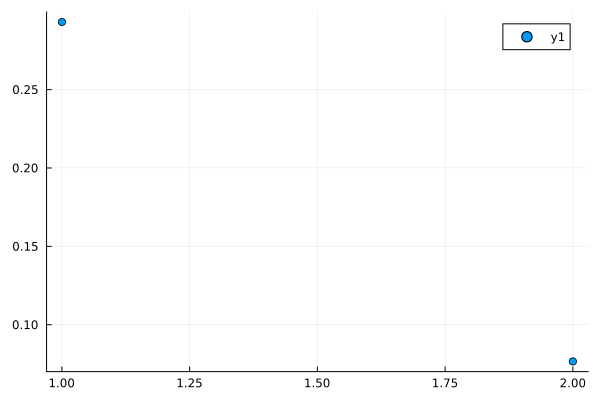

In [46]:
plot(reverse(data[:κ2_corrs][1,:]), seriestype=:scatter)

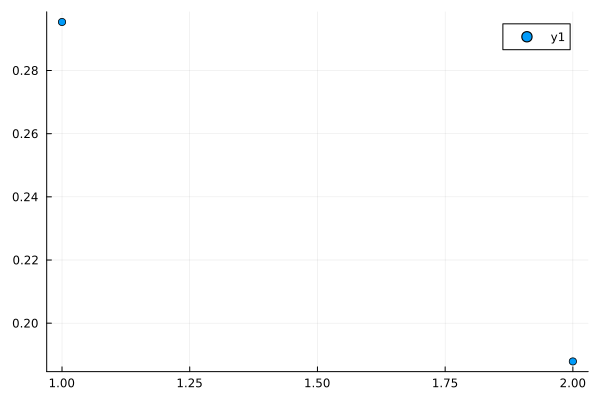

In [47]:
plot(reverse(data[:κ1_corrs_TCI][1,:]), seriestype=:scatter)

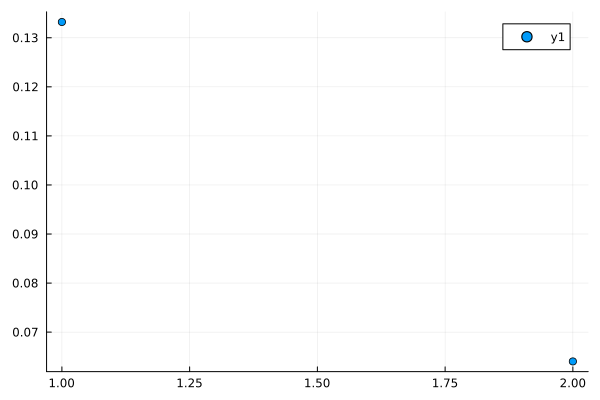

In [48]:
plot(reverse(data[:κ1_corrs_sampled][1,:]), seriestype=:scatter)

In [331]:
data[:κ1_corrs_sampled]

17×8 Matrix{Float64}:
 0.0          0.0          0.0          …  0.0          0.0
 3.37409e-21  3.74899e-21  3.03668e-19     2.0892e-17   0.000457247
 1.39683e-17  1.92498e-18  5.69569e-17     1.31246e-15  0.00345518
 4.18879e-17  2.65364e-16  2.15243e-15     8.07726      0.0349459
 4.75939e-15  1.2064e-7    3.67837e-5      0.0612843    0.0269169
 0.000345422  3.59912e-15  2.53043e-6   …  0.181293     0.00622679
 5.45517e-5   0.000234492  7.73439e-5      0.0123242    0.078289
 2.75299e-14  0.0543327    0.0127173       0.192646     0.109681
 0.00118197   2.72594e-14  0.0825632       0.0620338    0.445639
 6.74112e-13  1.16392e-14  0.00072915      1.31308e-13  0.491385
 9.79045e-15  1.07631e-14  0.00435869   …  0.129121     0.0949373
 8.8159e-14   0.00476708   0.0020603       0.0876364    0.40464
 4.1797e-14   2.9016e-14   0.004885        0.224232     2.79938e-13
 0.0149168    0.0160364    0.0156788       0.710002     0.19135
 0.000264598  5.8009e-14   0.00156726      0.0644311    0.3809

In [281]:
ψ1 = tci(state; n_initialpivots=40, tol=1e-8, maxdim=3*maxlinkdim(state.mps))

40-element MPS:
 ((dim=2|id=424|"Qubit,Site,n=1"), (dim=2|id=986|"l=1,link"))
 ((dim=2|id=986|"l=1,link"), (dim=2|id=653|"Qubit,Site,n=2"), (dim=4|id=285|"l=2,link"))
 ((dim=4|id=285|"l=2,link"), (dim=2|id=566|"Qubit,Site,n=3"), (dim=8|id=241|"l=3,link"))
 ((dim=8|id=241|"l=3,link"), (dim=2|id=795|"Qubit,Site,n=4"), (dim=16|id=865|"l=4,link"))
 ((dim=16|id=865|"l=4,link"), (dim=2|id=989|"Qubit,Site,n=5"), (dim=32|id=936|"l=5,link"))
 ((dim=32|id=936|"l=5,link"), (dim=2|id=482|"Qubit,Site,n=6"), (dim=51|id=49|"l=6,link"))
 ((dim=51|id=49|"l=6,link"), (dim=2|id=640|"Qubit,Site,n=7"), (dim=51|id=449|"l=7,link"))
 ((dim=51|id=449|"l=7,link"), (dim=2|id=587|"Qubit,Site,n=8"), (dim=51|id=218|"l=8,link"))
 ((dim=51|id=218|"l=8,link"), (dim=2|id=982|"Qubit,Site,n=9"), (dim=51|id=192|"l=9,link"))
 ((dim=51|id=192|"l=9,link"), (dim=2|id=326|"Qubit,Site,n=10"), (dim=51|id=15|"l=10,link"))
 ⋮
 ((dim=51|id=421|"l=31,link"), (dim=2|id=849|"Qubit,Site,n=32"), (dim=51|id=497|"l=32,link"))
 ((dim=51|id

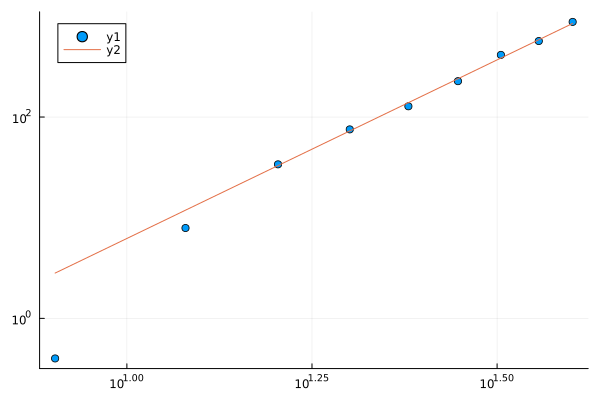

In [284]:
xs = [8, 12, 16, 20, 24, 28, 32, 36, 40]
ys = [0.4, 7.9, 33.9, 75.4, 127.9, 227.2, 414.5, 568.8, 881.3]
plot(xs, ys, xscale=:log10, yscale=:log10, seriestype=:scatter)

plot!(xs, f.(xs))

In [285]:
f(x) = exp(coeffs[2]) * x ^ coeffs[1]

f (generic function with 1 method)

In [351]:
f(64)/60/60

1.2536027828602465

In [283]:
using LinearAlgebra

# Extract subset [3:6]
xs_subset = xs[3:end]
ys_subset = ys[3:end]

# Perform linear fit in log-log space
A = [log.(xs_subset) ones(length(xs_subset))]
coeffs = A \ log.(ys_subset)
slope = coeffs[1]

println("Slope coefficient: $slope")

Slope coefficient: 3.5481564069704237


In [224]:
ψ1[2]

2×2×4 Array{Float64, 3}:
[:, :, 1] =
 1.0  0.0
 0.0  0.0

[:, :, 2] =
 0.0  1.0
 0.0  0.0

[:, :, 3] =
 0.0  0.0
 1.0  0.0

[:, :, 4] =
 0.0  0.0
 0.0  1.0

In [235]:
bits = [0,1,1,0]
bits = [0,1,0,1]
state = normalize(state)
println(get_sqrtprob_vec(state.mps, bits) )

0.25928256310056796


In [236]:
[get_prob_vec(state.mps, bits)
        for bits in Iterators.product(fill(0:1, L)...)
        if sum(bits) == L ÷ 2]

6-element Vector{Float64}:
 0.18962424439199999
 0.36531960752800036
 0.1812193480800001
 0.18121934808000004
 0.067227447528
 0.015390004392000034

In [237]:
[get_prob_vec(ψ1, bits)^2
        for bits in Iterators.product(fill(0:1, L)...)
        if sum(bits) == L ÷ 2]

6-element Vector{Float64}:
 0.1896242443919997
 0.3653196075279998
 0.18121934807999968
 0.18121934807999973
 0.06722744752799989
 0.01539000439200001

In [204]:
p = sum(get_prob_vec(state.mps, bits)
        for bits in Iterators.product(fill(0:1, L)...)
        if sum(bits) == L ÷ 2)

1.0000000000000004

In [205]:
p = sum(get_prob_vec(ψ1, bits)^2
        for bits in Iterators.product(fill(0:1, L)...)
        if sum(bits) == L ÷ 2)

0.999999999999999

In [201]:
bits = [0,1,1,0]
bits = [0,1,0,1]
ψ1 /= norm(ψ1)
println(get_prob_vec(ψ1, bits))

0.2592825631005678


In [176]:
ψ1 /= norm(ψ1)
println(get_prob_vec(ψ1, [1,0])^2)

0.8200000000000002


In [ ]:
get_sqrtprob_vec(normalize(state).mps, []])

0.9055385138137417

In [106]:
to_vector(ITensorMPS.state(siteinds(state.mps)[1], "0"))

2-element Vector{ComplexF64}:
 1.0 + 0.0im
 0.0 + 0.0im

In [ ]:
# function correlation_sweep(ψ::MPS, op1::String, op2::String)
#     ψ /= exp(lognorm(ψ))
#     L = length(ψ)

#     output_sweep = zeros(ComplexF64, L÷2)

#     middle_stacks = Vector{ITensor}(undef, L÷2)
#     middle_stacks[1] = ITensor(1)
#     for k in 1:L÷2-1
#         i = L÷2 - k + 1
#         j = L÷2 + k
#         si = siteinds(ψ)[i]
#         sj = siteinds(ψ)[j]
#         middle_stacks[k+1] = middle_stacks[k] * ψ[i] * dag(prime(ψ[i], !si)) * ψ[j] * dag(prime(ψ[j], !sj))
#     end

#     left_stack = ITensor(1)
#     right_stack = ITensor(1)
#     for i in 1:L÷2
#         j = L - i + 1

#         si = siteinds(ψ)[i]
#         sj = siteinds(ψ)[j]

#         mat_i = ψ[i] * op(op1, siteinds(ψ)[i]) * dag(prime(ψ[i]))
#         mat_j = ψ[j] * op(op2, siteinds(ψ)[j]) * dag(prime(ψ[j]))
        
#         output_sweep[L÷2-i+1] = reduce(*, [left_stack, mat_i, middle_stacks[L÷2-i+1], mat_j, right_stack])[]
#         left_stack = left_stack * ψ[i] * dag(prime(ψ[i], !si))
#         right_stack = ψ[j] * dag(prime(ψ[j], !sj)) * right_stack
#     end

#     return output_sweep
# end

correlation_sweep (generic function with 1 method)

In [ ]:
# correlation_sweep(state.mps, "a†", "a");

In [95]:
correlation_matrix(state.mps, "a†", "a");

In [93]:
L = 128
T = L
p = 0.1
# observables = [:χ2_corrs]
observables = Symbol[]

state = neel_state(DiagonalStateMPS, L)
state, data = circuit(state, L, T, p; observables=observables)

(DiagonalStateMPS(MPS(128)), Dict{Symbol, Array}())

In [24]:
L = 64
T = L
p = 0.1
observables = [:χ2]

state = neel_state(DiagonalStateMPS, L)
state, data = circuit(state, L, T, p; observables=observables)

(DiagonalStateMPS(MPS(64)), Dict{Symbol, Array}(:χ2 => [0.0, 0.2658889728696229, 0.5788528445025786, 0.8684893143796577, 1.1125855786269843, 1.323196458805527, 1.513876471140887, 1.6927735183440094, 1.8640058340023506, 2.029555603974818  …  7.044559677233729, 7.119788205551012, 7.193994492783623, 7.267194469611795, 7.339411043617433, 7.410859636321056, 7.481377816102903, 7.550980709344545, 7.6196767504828875, 7.687503010676267]))

In [16]:
ψ = state.mps
ψ /= norm(ψ)
[sample(ψ) for _ in 1:10]

10-element Vector{Vector{Int64}}:
 [1, 2, 1, 2, 1, 1, 2, 2]
 [1, 2, 1, 1, 1, 2, 2, 2]
 [1, 1, 2, 1, 1, 2, 2, 2]
 [2, 1, 2, 1, 1, 1, 2, 2]
 [2, 1, 2, 1, 1, 2, 1, 2]
 [1, 2, 2, 1, 1, 2, 2, 1]
 [1, 2, 1, 1, 1, 2, 2, 2]
 [2, 1, 2, 1, 1, 1, 2, 2]
 [1, 1, 1, 2, 1, 2, 2, 2]
 [2, 1, 1, 2, 2, 2, 1, 1]